In [3]:
!pip install scikit_posthocs

In [ ]:
import scikit_posthocs as sp

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, accuracy_score
from scipy.stats import friedmanchisquare, wilcoxon
import scikit_posthocs as sp

# Paso 1: Cargar y preparar los datos del Titanic
data = sns.load_dataset('titanic')

# Limpiar los datos (eliminar columnas no relevantes y manejar valores nulos)
data = data.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male', 'alone'])
data.dropna(subset=['embarked', 'age', 'fare'], inplace=True)

# Crear variables dummies para variables categóricas
data = pd.get_dummies(data, columns=['sex', 'embarked'], drop_first=True)

# Definir variables dependientes e independientes
X = data[['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']]
y = data['survived']

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=1,
                                                    stratify=y)

# Paso 2: Modelos
clf1 = LogisticRegression(multi_class='multinomial',
                          solver='newton-cg',
                          random_state=1)
clf2 = KNeighborsClassifier(algorithm='ball_tree',
                            leaf_size=50)
clf3 = DecisionTreeClassifier(random_state=1)

clf4 = SVC(random_state=1)

# Building the pipelines
pipe1 = Pipeline([('std', StandardScaler()), ('clf1', clf1)])
pipe2 = Pipeline([('std', StandardScaler()), ('clf2', clf2)])
pipe3 = Pipeline([('clf3', clf3)])  # No requiere estandarización
pipe4 = Pipeline([('std', StandardScaler()), ('clf4', clf4)])




# Setting up the parameter grids
param_grid1 = [{'clf1__penalty': ['l2'],
                'clf1__C': np.power(10., np.arange(-4, 4))}]

param_grid2 = [{'clf2__n_neighbors': list(range(1, 10)),
                'clf2__p': [1, 2]}]

param_grid3 = [{'max_depth': list(range(1, 10)) + [None],
                'criterion': ['gini', 'entropy']}]

param_grid4 = [{'clf4__kernel': ['rbf'],
                'clf4__C': np.power(10., np.arange(-4, 4)),
                'clf4__gamma': np.power(10., np.arange(-5, 0))},
               {'clf4__kernel': ['linear'],
                'clf4__C': np.power(10., np.arange(-4, 4))}]


# Definir los modelos y sus correspondientes pipelines
models = {
    'Logistic Regression': pipe1,
    'K-Nearest Neighbors': pipe2,
    'Decision Tree': pipe3,
    'SVM': pipe4
}

# Definir los grids de hiperparámetros
param_grid = {
    'Logistic Regression': {'clf1__C': np.power(10., np.arange(-4, 4))},
    'K-Nearest Neighbors': {'clf2__n_neighbors': list(range(1, 10)), 'clf2__p': [1, 2]},
    'Decision Tree': {'clf3__max_depth': list(range(1, 10)) + [None], 'clf3__criterion': ['gini', 'entropy']},
    'SVM': [{'clf4__kernel': ['rbf'], 'clf4__C': np.power(10., np.arange(-4, 4)), 'clf4__gamma': np.power(10., np.arange(-5, 0))},
            {'clf4__kernel': ['linear'], 'clf4__C': np.power(10., np.arange(-4, 4))}]
}




In [ ]:
# Paso 3: Búsqueda de hiperparámetros con validación cruzada
best_models = {}
cv_results = {}

# Gráficas para almacenar los resultados de la búsqueda de hiperparámetros
grid_search_results = {}

for model_name, model in models.items():
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid[model_name], cv=5, scoring='accuracy', return_train_score=True)
    grid_search.fit(X_train, y_train)

    best_models[model_name] = grid_search.best_estimator_
    cv_scores = cross_val_score(best_models[model_name], X_train, y_train, cv=5, scoring='accuracy')
    cv_results[model_name] = cv_scores

    grid_search_results[model_name] = pd.DataFrame(grid_search.cv_results_)

    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"{model_name} - Cross-Validation Mean Accuracy: {cv_scores.mean():.4f}, Standard Deviation: {cv_scores.std():.4f}\n")



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' w

Best parameters for Logistic Regression: {'clf1__C': 1.0}
Logistic Regression - Cross-Validation Mean Accuracy: 0.7943, Standard Deviation: 0.0401

Best parameters for K-Nearest Neighbors: {'clf2__n_neighbors': 4, 'clf2__p': 1}
K-Nearest Neighbors - Cross-Validation Mean Accuracy: 0.8225, Standard Deviation: 0.0276

Best parameters for Decision Tree: {'clf3__criterion': 'entropy', 'clf3__max_depth': 5}
Decision Tree - Cross-Validation Mean Accuracy: 0.8101, Standard Deviation: 0.0203

Best parameters for SVM: {'clf4__C': 1.0, 'clf4__gamma': 0.1, 'clf4__kernel': 'rbf'}
SVM - Cross-Validation Mean Accuracy: 0.8136, Standard Deviation: 0.0335



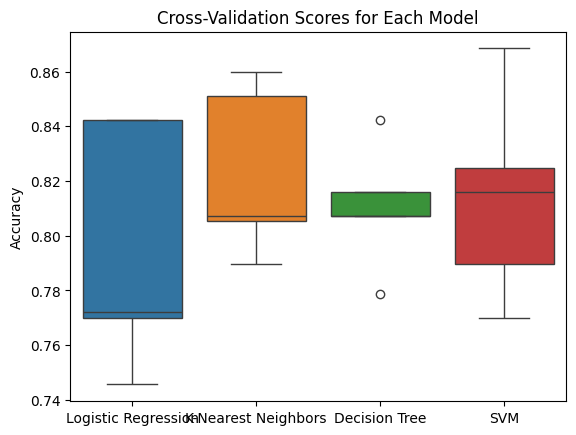

In [ ]:
# Paso 4: Gráfica de caja para comparar los resultados de cada algoritmo
cv_scores_df = pd.DataFrame(cv_results)
sns.boxplot(data=cv_scores_df)
plt.title('Cross-Validation Scores for Each Model')
plt.ylabel('Accuracy')
plt.show()

## El Test de Friedman

El Test de Friedman es un test no paramétrico que se utiliza para comparar tres o más grupos relacionados. En este caso, se emplea para determinar si existen diferencias significativas en el rendimiento de varios modelos de Machine Learning cuando se evalúan bajo las mismas condiciones (por ejemplo, mediante validación cruzada).

El test de Friedman evalúa si las distribuciones de los resultados de los modelos son significativamente diferentes. Esto se logra evaluando los rankings de cada modelo en cada corrida de validación cruzada. Si el estadístico del test de Friedman indica una diferencia significativa (un valor p bajo, generalmente < 0.05), sugiere que al menos uno de los modelos tiene un rendimiento diferente a los demás. Sin embargo, el test no especifica entre cuáles modelos se encuentran las diferencias; para eso se realizan pruebas post-hoc (como la prueba de Tukey o el test de Nemenyi) para identificar específicamente cuáles pares de modelos difieren entre sí.

En resumen, el Test de Friedman responde a la pregunta: "¿Existen diferencias significativas en el rendimiento promedio de los modelos evaluados?"

In [ ]:
# Paso 6: Comparación de los algoritmos usando el Test de Friedman
scores_friedman = np.array([cv_results[model] for model in models])
stat, p_value = friedmanchisquare(*scores_friedman)

print(f'Friedman Test Statistic: {stat}')
print(f'p-value: {p_value}\n')


Friedman Test Statistic: 2.7391304347826044
p-value: 0.43361839268197233



### ¿Qué significa este análisis post-hoc?

- **Test de Nemenyi**: Es un procedimiento post-hoc no paramétrico que se utiliza para hacer comparaciones por pares entre grupos cuando se ha encontrado una diferencia significativa en un análisis como el Test de Friedman. Es ideal para comparar modelos o algoritmos cuando los datos no son necesariamente normales o las varianzas no son iguales.

- **`sp.posthoc_nemenyi_friedman`**: Esta función específica de la biblioteca `scikit-posthocs` realiza la prueba de Nemenyi tras haber ejecutado el Test de Friedman. La prueba de Nemenyi compara todos los pares de grupos (en este caso, los diferentes modelos) y evalúa si hay diferencias significativas entre ellos.

### ¿Qué representa la salida?

La variable `posthoc_results` será una **matriz de valores p** que muestran los resultados de las comparaciones por pares entre cada uno de los modelos. Cada celda de la matriz representa el **valor p** de la comparación entre dos modelos. Si el valor p es menor que un umbral predefinido (por ejemplo, 0.05), significa que hay una diferencia significativa en el rendimiento entre los dos modelos comparados.

### La transposición `scores_friedman.T`:

La transposición `scores_friedman.T` es necesaria para organizar correctamente los datos. Dado que el test de Nemenyi espera que las comparaciones se realicen entre las columnas, estamos transponiendo la matriz `scores_friedman`, que originalmente tiene los modelos como filas. Esto asegura que los modelos se comparen entre sí adecuadamente en las columnas.


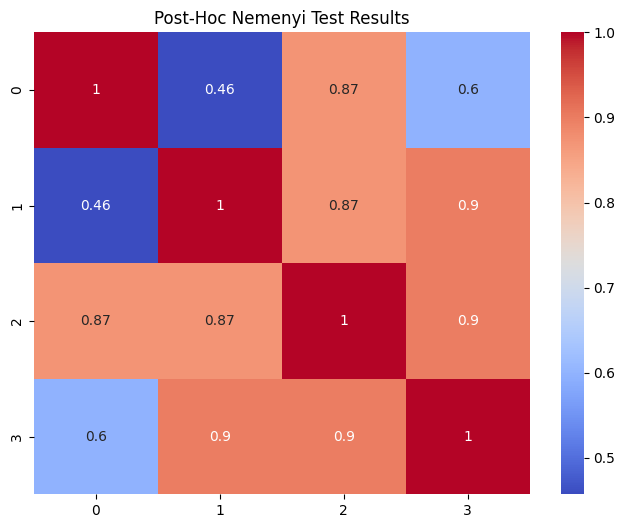

In [ ]:
# Paso 7: Test de post-hoc usando scikit-posthocs
posthoc_results = sp.posthoc_nemenyi_friedman(scores_friedman.T)

# Mostrar resultados post-hoc
plt.figure(figsize=(8, 6))
sns.heatmap(posthoc_results, annot=True, cmap='coolwarm', cbar=True)
plt.title('Post-Hoc Nemenyi Test Results')
plt.show()



In [ ]:
# Mostrar intervalos de confianza (bootstrapping)
for model_name, scores in cv_results.items():
    mean_score = np.mean(scores)
    ci_lower = np.percentile(scores, 2.5)
    ci_upper = np.percentile(scores, 97.5)
    print(f'{model_name} - Mean: {mean_score:.4f}, 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')

Logistic Regression - Mean: 0.7943, 95% CI: [0.7480, 0.8421]
K-Nearest Neighbors - Mean: 0.8225, 95% CI: [0.7911, 0.8588]
Decision Tree - Mean: 0.8101, 95% CI: [0.7816, 0.8395]
SVM - Mean: 0.8136, 95% CI: [0.7719, 0.8640]


Aquí vamosa a suponer que el mejor de los algoritmos fue el SVM ... recuerde que las pruebas distan de este resultado.

In [ ]:
# Ajustar el modelo al conjunto completo de entrenamiento utilizando el mejor algoritmo
best_algo = best_models['SVM']  # Reemplaza 'mejor_algoritmo' con el nombre del mejor algoritmo

# Entrenar el modelo en el conjunto de entrenamiento completo
best_algo.fit(X_train, y_train)

# Calcular la precisión en el conjunto de entrenamiento
train_acc = accuracy_score(y_true=y_train, y_pred=best_algo.predict(X_train))

# Calcular la precisión en el conjunto de prueba
test_acc = accuracy_score(y_true=y_test, y_pred=best_algo.predict(X_test))

# Resultados
print('Training Accuracy: %.2f%%' % (100 * train_acc))
print('Test Accuracy: %.2f%%' % (100 * test_acc))

# Obtener los mejores parámetros del GridSearchCV
best_params = best_algo.named_steps['clf4'].get_params()  # 'clf4' es el nombre del clasificador SVM en el pipeline

print(f"Best Parameters: {best_params}")


Training Accuracy: 84.18%
Test Accuracy: 76.92%
Best Parameters: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 0.1, 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 1, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [ ]:
# Generar las estadisticas del modelo de clasificación
from sklearn.metrics import classification_report
print(classification_report(y_test, best_algo.predict(X_test)))


              precision    recall  f1-score   support

           0       0.75      0.92      0.83        85
           1       0.82      0.55      0.66        58

    accuracy                           0.77       143
   macro avg       0.79      0.73      0.74       143
weighted avg       0.78      0.77      0.76       143



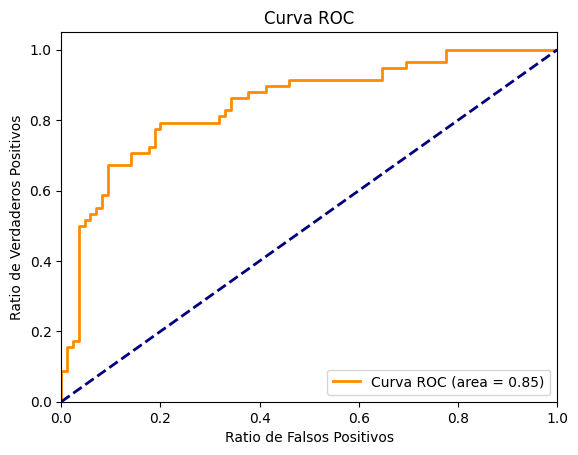

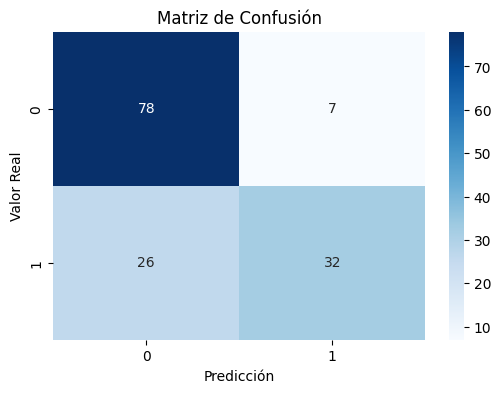

In [ ]:

from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Modificar el pipeline original para incluir probability=True en SVC
best_algo.named_steps['clf4'].probability = True  # Asegurarse de que 'clf4' es el nombre correcto del paso de SVM

# Volver a entrenar el modelo con la opción probability habilitada
best_algo.fit(X_train, y_train)

# Paso 5: Curva ROC y AUC para el mejor modelo
# Suponiendo que el mejor modelo es 'SVM'
y_pred_proba = best_algo.predict_proba(X_test)[:, 1]  # Probabilidad de pertenecer a la clase positiva (supervivencia)

# ... (El resto de tu código) ...
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Ratio de Falsos Positivos')
plt.ylabel('Ratio de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()


# Matriz de confusión
y_pred = best_algo.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()


### Para la regresión

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Paso 1: Cargar el conjunto de datos de California Housing
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Paso 2: Inicializar los modelos de regresión
clf1 = LinearRegression()
clf2 = RandomForestRegressor(random_state=1)
clf3 = SVR()

# Construir los pipelines
pipe1 = Pipeline([('std', StandardScaler()), ('clf1', clf1)])
pipe2 = Pipeline([('clf2', clf2)])  # RandomForest no necesita estandarización
pipe3 = Pipeline([('std', StandardScaler()), ('clf3', clf3)])

# Definir los modelos y sus correspondientes pipelines
models = {
    'Linear Regression': pipe1,
    'Random Forest': pipe2,
    'SVR': pipe3
}

# Paso 3: Definir los grids de hiperparámetros
param_grid = {
    'Linear Regression': {},
    'Random Forest': {'clf2__n_estimators': [50, 100, 200], 'clf2__max_depth': [None, 10, 20]},
    'SVR': {'clf3__C': np.power(10., np.arange(-4, 4)), 'clf3__gamma': np.power(10., np.arange(-5, 0))}
}

# Paso 4: Búsqueda de hiperparámetros con validación cruzada
best_models = {}
cv_results = {}

for model_name, model in models.items():
    grid_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid[model_name], cv=5, scoring='neg_mean_squared_error', return_train_score=True)
    grid_search.fit(X_train, y_train)

    best_models[model_name] = grid_search.best_estimator_
    cv_scores = cross_val_score(best_models[model_name], X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_results[model_name] = cv_scores

    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"{model_name} - Mean Cross-Validation MSE: {-cv_scores.mean():.4f}, Standard Deviation: {cv_scores.std():.4f}\n")




/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters for Linear Regression: {}
Linear Regression - Mean Cross-Validation MSE: 0.5282, Standard Deviation: 0.0198



/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters for Random Forest: {'clf2__n_estimators': 200, 'clf2__max_depth': None}
Random Forest - Mean Cross-Validation MSE: 0.2606, Standard Deviation: 0.0102

Best parameters for SVR: {'clf3__gamma': 0.1, 'clf3__C': 100.0}
SVR - Mean Cross-Validation MSE: 0.3230, Standard Deviation: 0.0065



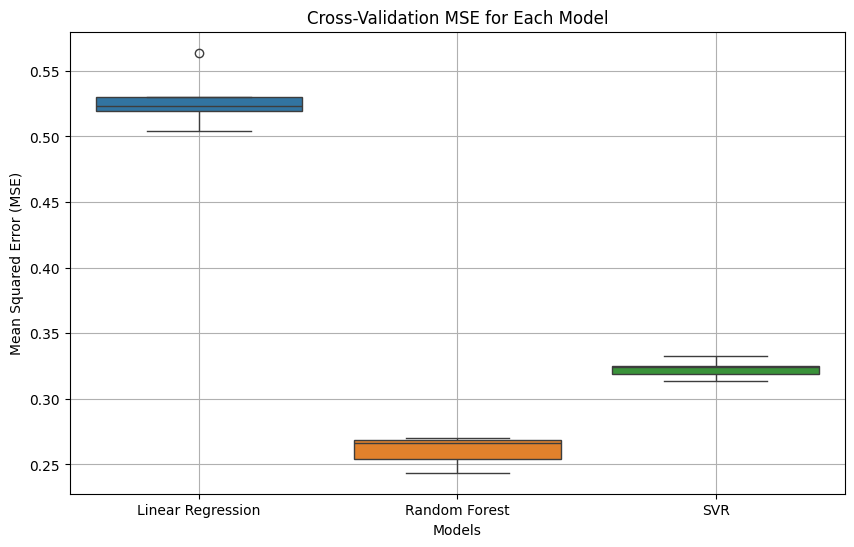

In [5]:
import seaborn as sns
# Paso 5: Crear un DataFrame para los resultados de validación cruzada
cv_scores_df = pd.DataFrame({model_name: -cv_results[model_name] for model_name in models})  # Invertimos el MSE para que sea positivo

# Gráfico de cajas para comparar los resultados de cada modelo
plt.figure(figsize=(10, 6))
sns.boxplot(data=cv_scores_df)
plt.title('Cross-Validation MSE for Each Model')
plt.ylabel('Mean Squared Error (MSE)')
plt.xlabel('Models')
plt.grid(True)
plt.show()


Friedman Test Statistic: 10.0
p-value: 0.006737946999085468

Diferencias significativas encontradas, realizando análisis post-hoc (Test de Nemenyi):


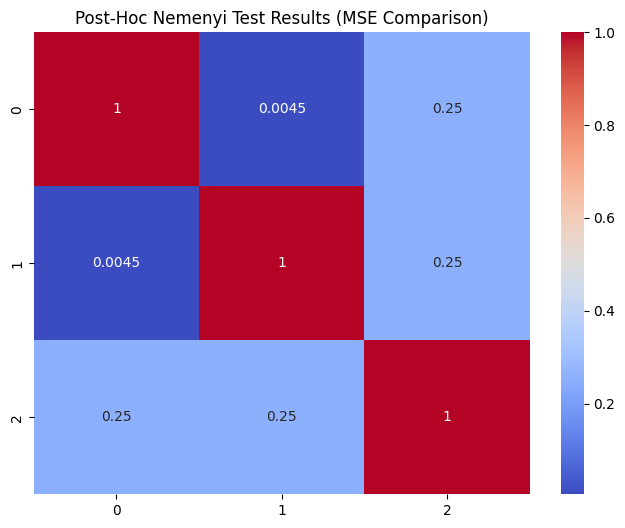

In [6]:
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp
import seaborn as sns

# Paso 6: Realizar el Test de Friedman para comparar los modelos
scores_friedman = np.array([-cv_results[model] for model in models])  # Invertimos el signo para convertir MSE a un criterio de maximización

stat, p_value = friedmanchisquare(*scores_friedman)

print(f'Friedman Test Statistic: {stat}')
print(f'p-value: {p_value}\n')

# Paso 7: Si el Test de Friedman muestra diferencias significativas, realizamos el post-hoc con Nemenyi
if p_value < 0.05:
    print("Diferencias significativas encontradas, realizando análisis post-hoc (Test de Nemenyi):")

    # Realizar el post-hoc utilizando el Test de Nemenyi
    posthoc_results = sp.posthoc_nemenyi_friedman(scores_friedman.T)

    # Mostrar resultados post-hoc como un mapa de calor
    plt.figure(figsize=(8, 6))
    sns.heatmap(posthoc_results, annot=True, cmap='coolwarm', cbar=True)
    plt.title('Post-Hoc Nemenyi Test Results (MSE Comparison)')
    plt.show()
else:
    print("No se encontraron diferencias significativas entre los modelos según el Test de Friedman.")


In [7]:
# Paso 5: Ajustar el mejor modelo al conjunto de entrenamiento completo y evaluar en el conjunto de prueba
best_algo = best_models['Random Forest']  # Aquí seleccionamos, por ejemplo, el mejor modelo Random Forest

# Entrenar el modelo en el conjunto de entrenamiento completo
best_algo.fit(X_train, y_train)

# Calcular la precisión en el conjunto de entrenamiento y prueba
y_train_pred = best_algo.predict(X_train)
y_test_pred = best_algo.predict(X_test)

# Métricas de rendimiento
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Imprimir los resultados
print(f'Training MSE: {train_mse:.4f}, Training R²: {train_r2:.4f}')
print(f'Test MSE: {test_mse:.4f}, Test R²: {test_r2:.4f}')

Training MSE: 0.0347, Training R²: 0.9740
Test MSE: 0.2517, Test R²: 0.8081
